In [66]:
from show_img import show_img
import numpy as np
import cv2

In [67]:
red = [0, 0, 255]
green = [0, 255, 0]
blue = [255, 0, 0]

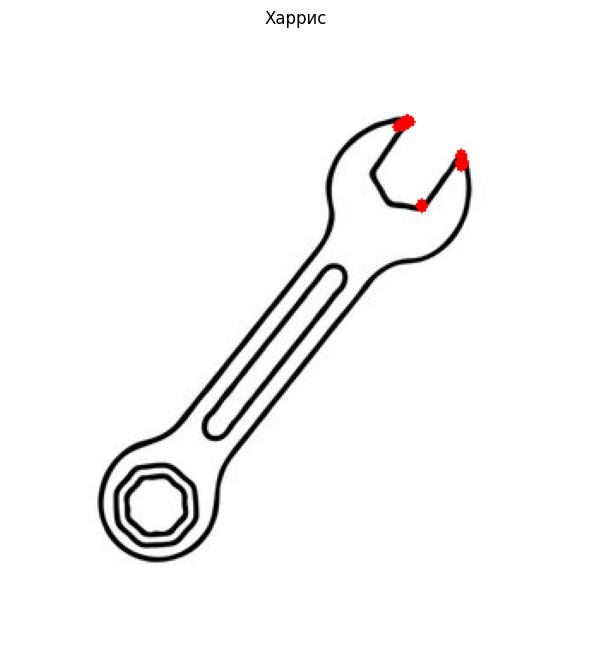

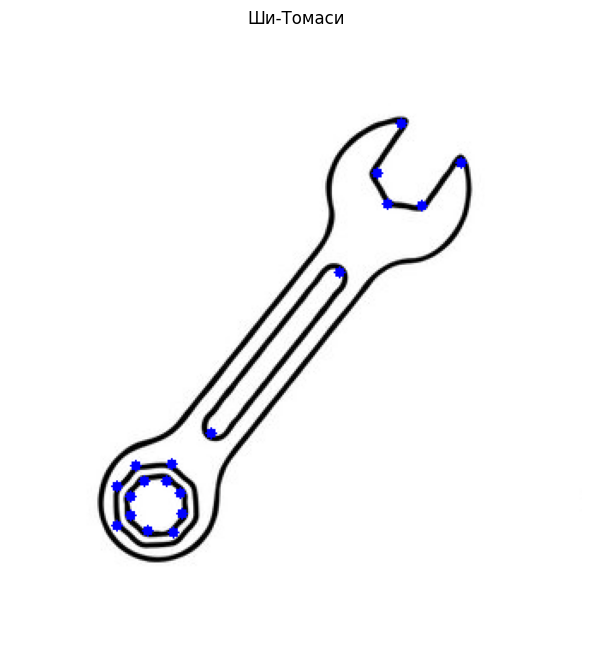

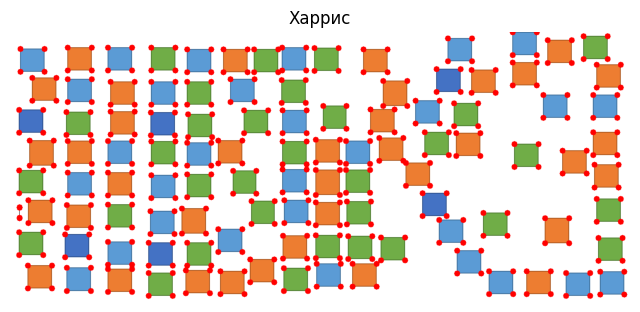

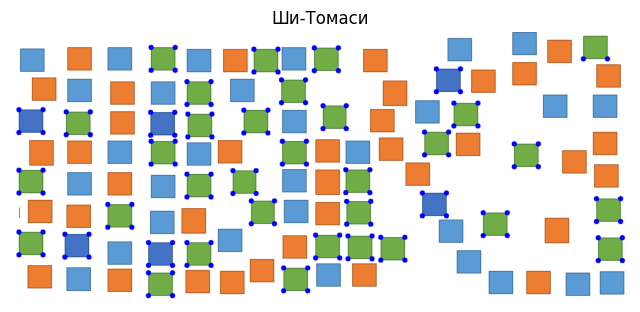

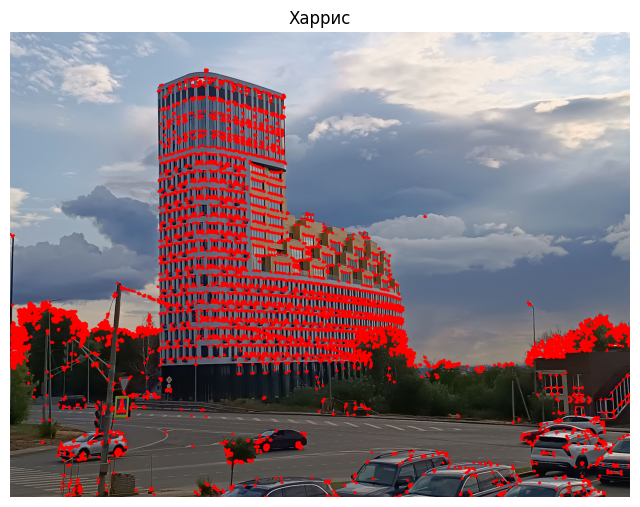

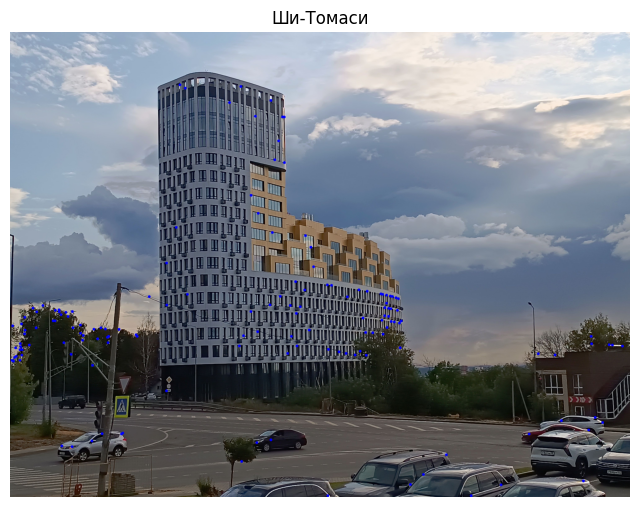

In [68]:
def detect_corners(img, size_mlt):
    img_shi = img.copy()
    img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    points = cv2.cornerHarris(img_grayscale, 2, 3, 0.04)
    thres = 0.01
    y_coords, x_coords = np.where(points > thres * points.max())
    for x, y in zip(x_coords, y_coords):
        cv2.circle(img, (x, y), 3 * size_mlt, red, -1)
    img[points > thres * points.max()] = red


    corners = cv2.goodFeaturesToTrack(img_grayscale, 150, 0.01, 10)
    corners = corners.astype(int) 
    
    for i in corners:
        x, y = i.ravel()
        cv2.circle(img_shi, (x, y), 3 * size_mlt, blue, -1)

    show_img(img, "Харрис", size=8)
    show_img(img_shi, "Ши-Томаси", size=8)


images = ['spanner.png', 
          "square_many2.jpg",
          "skyskeb_one.jpg", 
          ]


for i, img_path in enumerate(images):
    img1 = cv2.imread(img_path)
    if img_path == "skskyskeb_one.jpgy": i *= 2
    detect_corners(img1, i + 1)